# Uber Ride Cancellation Prediction - Model Building

## Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load prepared data
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

# Load target encoder
with open('target_encoder.pkl', 'rb') as f:
    target_encoder = pickle.load(f)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (111771, 10)
Validation set: (12547, 10)
Test set: (24449, 10)


In [3]:
# Feature names for reference
feature_names = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
                'vehicle_type', 'pickup_location', 'drop_location', 
                'payment_method', 'time_of_day']

# Class names
class_names = target_encoder.classes_
print(f"\nClasses: {class_names}")


Classes: ['Cancelled by Customer' 'Cancelled by Driver' 'Completed' 'Incomplete'
 'No Driver Found']


## Baseline Model

In [4]:
# Create baseline model 
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline.predict(X_val)

# Evaluation
baseline_accuracy = accuracy_score(y_val, y_pred_baseline)
baseline_f1_macro = f1_score(y_val, y_pred_baseline, average='macro')
baseline_f1_weighted = f1_score(y_val, y_pred_baseline, average='weighted')

print("Baseline Model (Most Frequent Class)")
print("=" * 50)
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"F1-Score (Macro): {baseline_f1_macro:.4f}")
print(f"F1-Score (Weighted): {baseline_f1_weighted:.4f}")

Baseline Model (Most Frequent Class)
Accuracy: 0.6250
F1-Score (Macro): 0.1538
F1-Score (Weighted): 0.4808


## Logistic Regression

In [5]:
# Train logistic regression with class weights to handle imbalance
logistic = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logistic.fit(X_train, y_train)

# Predictions
y_pred_logistic = logistic.predict(X_val)

# Evaluation
logistic_accuracy = accuracy_score(y_val, y_pred_logistic)
logistic_f1_macro = f1_score(y_val, y_pred_logistic, average='macro')
logistic_f1_weighted = f1_score(y_val, y_pred_logistic, average='weighted')

print("Logistic Regression")
print("=" * 50)
print(f"Accuracy: {logistic_accuracy:.4f}")
print(f"F1-Score (Macro): {logistic_f1_macro:.4f}")
print(f"F1-Score (Weighted): {logistic_f1_weighted:.4f}")

Logistic Regression
Accuracy: 0.4690
F1-Score (Macro): 0.3361
F1-Score (Weighted): 0.5336


In [6]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_logistic, target_names=class_names))


Classification Report:
                       precision    recall  f1-score   support

Cancelled by Customer       0.22      0.23      0.22       888
  Cancelled by Driver       0.56      0.22      0.31      2206
            Completed       0.90      0.56      0.69      7842
           Incomplete       0.08      0.42      0.14       751
      No Driver Found       0.22      0.55      0.32       860

             accuracy                           0.47     12547
            macro avg       0.40      0.39      0.34     12547
         weighted avg       0.70      0.47      0.53     12547



## Decision Tree

In [7]:
# Train decision tree with class weights
tree = DecisionTreeClassifier(class_weight='balanced', max_depth=10, 
                              min_samples_split=100, random_state=42)
tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_val)

# Evaluation
tree_accuracy = accuracy_score(y_val, y_pred_tree)
tree_f1_macro = f1_score(y_val, y_pred_tree, average='macro')
tree_f1_weighted = f1_score(y_val, y_pred_tree, average='weighted')

print("Decision Tree")
print("=" * 50)
print(f"Accuracy: {tree_accuracy:.4f}")
print(f"F1-Score (Macro): {tree_f1_macro:.4f}")
print(f"F1-Score (Weighted): {tree_f1_weighted:.4f}")

Decision Tree
Accuracy: 0.3205
F1-Score (Macro): 0.2874
F1-Score (Weighted): 0.3821


In [8]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_tree, target_names=class_names))


Classification Report:
                       precision    recall  f1-score   support

Cancelled by Customer       0.22      0.31      0.26       888
  Cancelled by Driver       0.55      0.17      0.27      2206
            Completed       0.91      0.31      0.46      7842
           Incomplete       0.09      0.70      0.16       751
      No Driver Found       0.21      0.50      0.30       860

             accuracy                           0.32     12547
            macro avg       0.40      0.40      0.29     12547
         weighted avg       0.70      0.32      0.38     12547



## Random Forest

In [9]:
# Train random forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                            max_depth=15, min_samples_split=50, 
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_val)

# Evaluation
rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_f1_macro = f1_score(y_val, y_pred_rf, average='macro')
rf_f1_weighted = f1_score(y_val, y_pred_rf, average='weighted')

print("Random Forest")
print("=" * 50)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1-Score (Macro): {rf_f1_macro:.4f}")
print(f"F1-Score (Weighted): {rf_f1_weighted:.4f}")

Random Forest
Accuracy: 0.7109
F1-Score (Macro): 0.3859
F1-Score (Weighted): 0.7016


In [10]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf, target_names=class_names))


Classification Report:
                       precision    recall  f1-score   support

Cancelled by Customer       0.22      0.28      0.25       888
  Cancelled by Driver       0.55      0.38      0.45      2206
            Completed       0.91      0.96      0.94      7842
           Incomplete       0.09      0.04      0.06       751
      No Driver Found       0.20      0.30      0.24       860

             accuracy                           0.71     12547
            macro avg       0.39      0.39      0.39     12547
         weighted avg       0.70      0.71      0.70     12547



## Model Comparison

In [11]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [baseline_accuracy, logistic_accuracy, tree_accuracy, rf_accuracy],
    'F1 (Macro)': [baseline_f1_macro, logistic_f1_macro, tree_f1_macro, rf_f1_macro],
    'F1 (Weighted)': [baseline_f1_weighted, logistic_f1_weighted, tree_f1_weighted, rf_f1_weighted]
})

print("\nModel Comparison:")
print("=" * 70)
print(results.to_string(index=False))


Model Comparison:
              Model  Accuracy  F1 (Macro)  F1 (Weighted)
           Baseline  0.625010    0.153848       0.480782
Logistic Regression  0.468957    0.336139       0.533631
      Decision Tree  0.320475    0.287373       0.382119
      Random Forest  0.710927    0.385865       0.701623


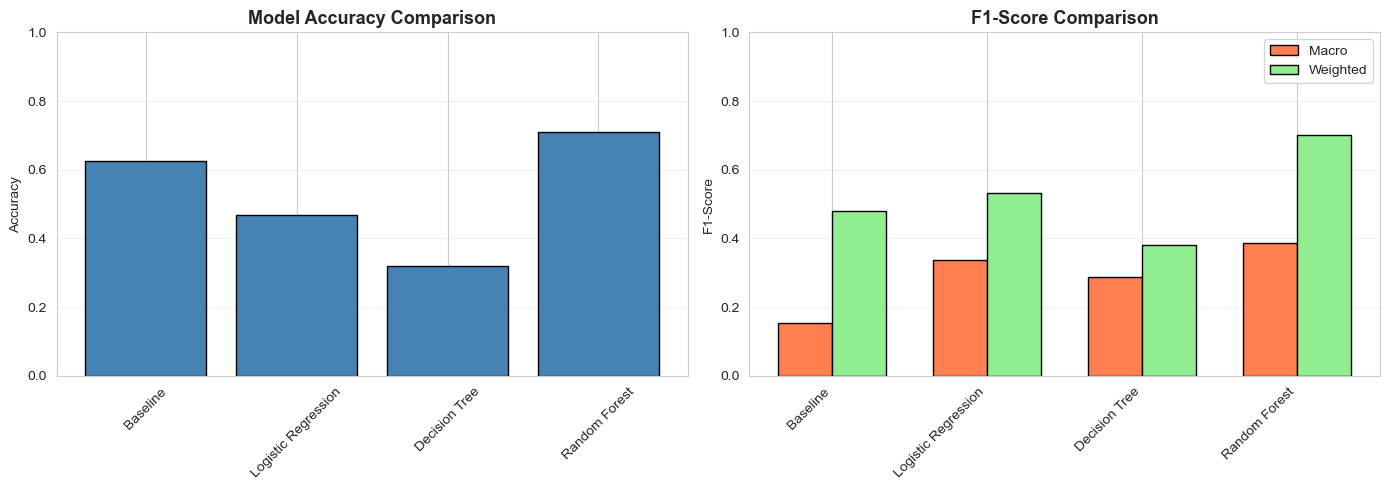

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(results['Model'], results['Accuracy'], color='steelblue', edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# F1-Score comparison
x = np.arange(len(results))
width = 0.35
axes[1].bar(x - width/2, results['F1 (Macro)'], width, label='Macro', color='coral', edgecolor='black')
axes[1].bar(x + width/2, results['F1 (Weighted)'], width, label='Weighted', color='lightgreen', edgecolor='black')
axes[1].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance Analysis

In [13]:
# Get feature importance from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices],
    'Importance': importances[indices]
})

print("Feature Importance (Random Forest):")
print("=" * 50)
print(feature_importance_df.to_string(index=False))

Feature Importance (Random Forest):
        Feature  Importance
 payment_method    0.732685
  drop_location    0.070862
pickup_location    0.070404
           hour    0.034482
          month    0.029417
   vehicle_type    0.024301
    day_of_week    0.021099
    time_of_day    0.008612
   is_peak_hour    0.004476
     is_weekend    0.003664


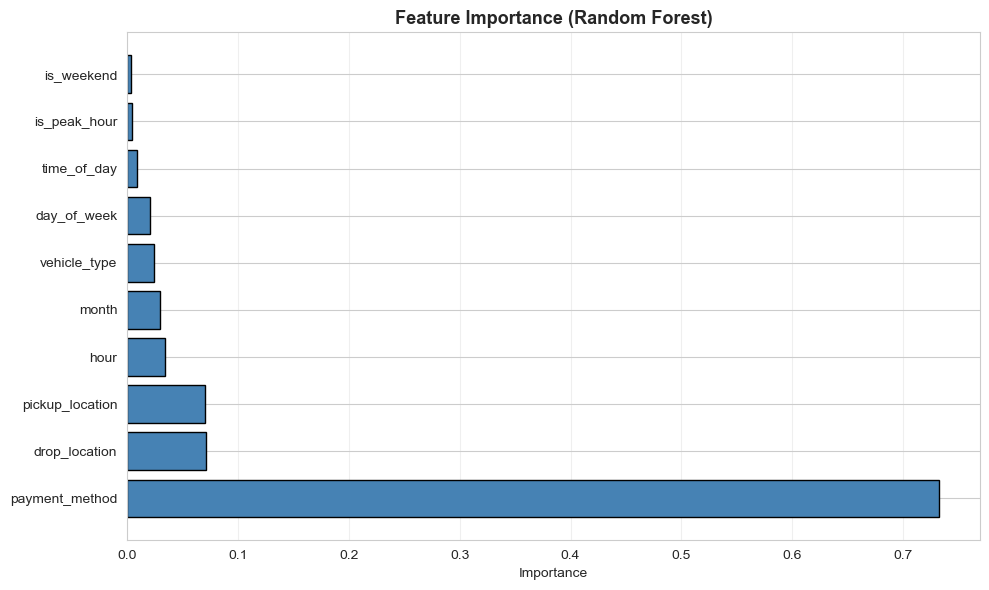

In [14]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], color='steelblue', edgecolor='black')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Evaluation on Test Set

In [15]:
# Predictions on test set
y_pred_test = rf.predict(X_test)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1_macro = f1_score(y_test, y_pred_test, average='macro')
test_f1_weighted = f1_score(y_test, y_pred_test, average='weighted')

print("Final Test Set Performance (Random Forest)")
print("=" * 50)
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1-Score (Macro): {test_f1_macro:.4f}")
print(f"F1-Score (Weighted): {test_f1_weighted:.4f}")

Final Test Set Performance (Random Forest)
Accuracy: 0.7078
F1-Score (Macro): 0.3864
F1-Score (Weighted): 0.6985


In [16]:
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=class_names))


Detailed Classification Report:
                       precision    recall  f1-score   support

Cancelled by Customer       0.21      0.28      0.24      1716
  Cancelled by Driver       0.57      0.38      0.46      4397
            Completed       0.91      0.96      0.93     15157
           Incomplete       0.08      0.03      0.05      1498
      No Driver Found       0.21      0.32      0.25      1681

             accuracy                           0.71     24449
            macro avg       0.40      0.40      0.39     24449
         weighted avg       0.70      0.71      0.70     24449



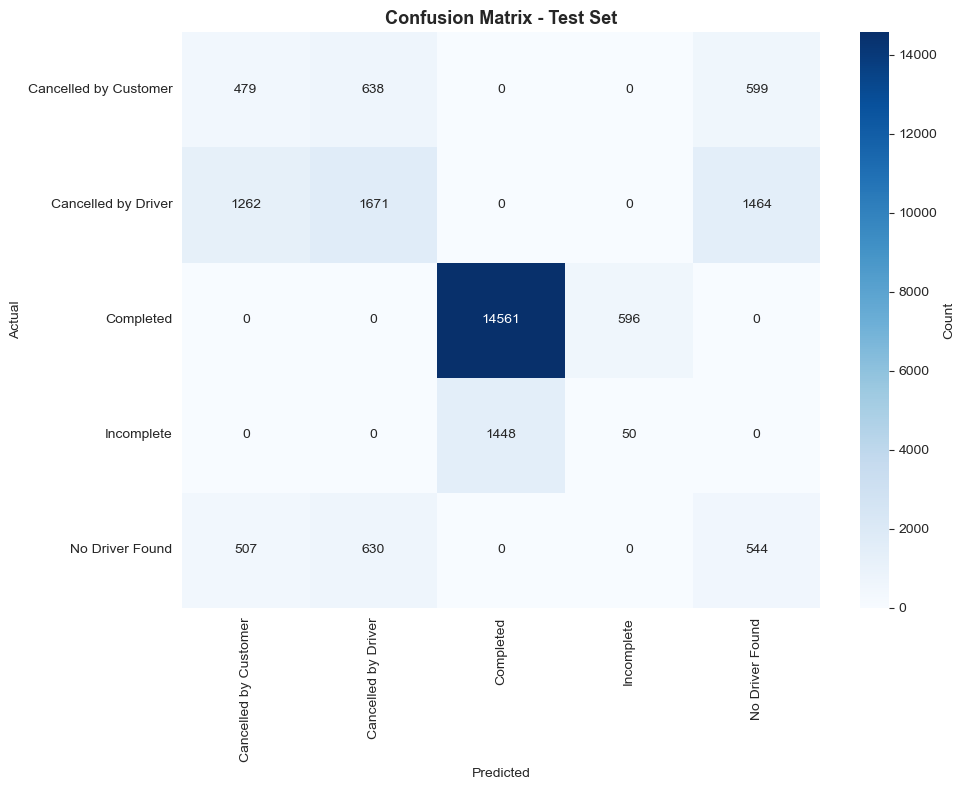

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

### Per-Class Performance Analysis

In [18]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_test)

per_class_metrics = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-Class Performance:")
print("=" * 80)
print(per_class_metrics.to_string(index=False))


Per-Class Performance:
                Class  Precision   Recall  F1-Score  Support
Cancelled by Customer   0.213078 0.279138  0.241675     1716
  Cancelled by Driver   0.568561 0.380032  0.455562     4397
            Completed   0.909551 0.960678  0.934416    15157
           Incomplete   0.077399 0.033378  0.046642     1498
      No Driver Found   0.208669 0.323617  0.253731     1681


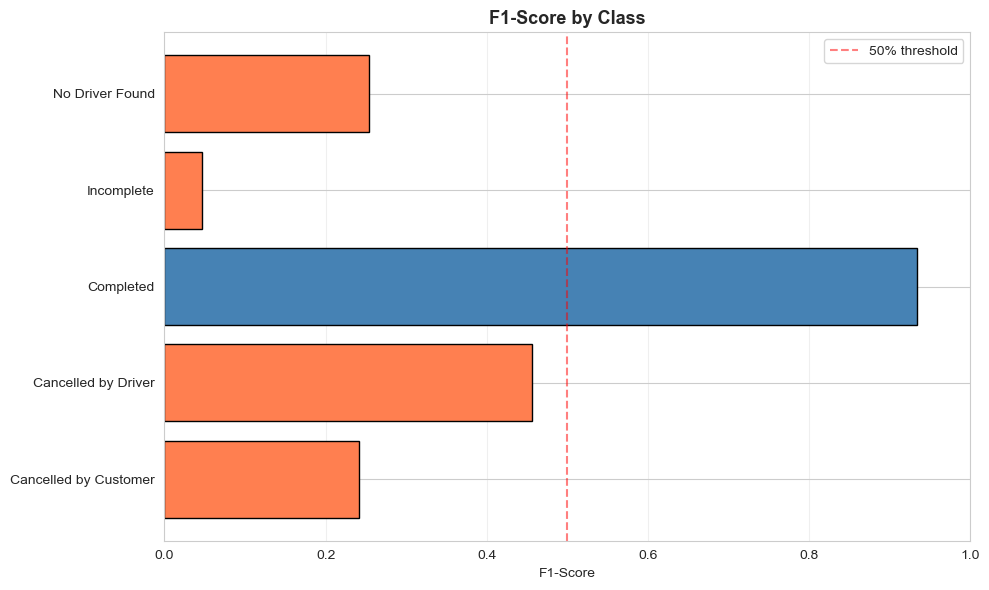

In [19]:
plt.figure(figsize=(10, 6))
colors = ['coral' if f < 0.5 else 'lightgreen' if f < 0.7 else 'steelblue' for f in f1]
plt.barh(class_names, f1, color=colors, edgecolor='black')
plt.xlabel('F1-Score')
plt.title('F1-Score by Class', fontsize=13, fontweight='bold')
plt.xlim([0, 1])
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

### Save Final Model

In [20]:
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved successfully")

Model saved successfully
